# Taller: Representaciones de Texto - Word Embeddings y Embedding Contextual
## Curso de Inteligencia Artificial
---

En este taller explorarás de forma práctica cómo los embeddings transforman palabras en vectores numéricos que capturan relaciones semánticas y sintácticas.

**OBJETIVO**: 

- Completa cada sección escribiendo el código Python necesario para lograr los objetivos especificados.
- Usa las instrucciones y pistas en cada celda para guiarte en la solución.


## 1. Instalación de Dependencias

Primero, instalaremos las librerías necesarias:

In [1]:
# TODO: Instalar las siguientes librerías
# - gensim
# - nltk  
# - scikit-learn
# - matplotlib
# - numpy
# 
# INSTRUCCIONES:
# 1. Importa subprocess y sys
# 2. Crea una lista llamada 'librerías' con las librerías mencionadas
# 3. Usa un loop para instalar cada una con pip install
# 4. Imprime un mensaje de confirmación al final

import subprocess
import sys

librerías = ['gensim', 'nltk', 'scikit-learn', 'matplotlib', 'numpy']

for lib in librerías:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', lib])

print("Todas las librerías han sido instaladas.")


Todas las librerías han sido instaladas.


## 2. Conceptos Fundamentales

In [ ]:
# TODO: Comparar One-Hot Encoding vs Dense Embeddings
# 
# INSTRUCCIONES:
# 1. Define un vocabulario: ['inteligencia', 'artificial', 'máquina', 'aprendizaje', 'datos']
# 2. Crea un vector One-Hot para la primera palabra (todos ceros excepto el índice 0)
# 3. Crea un embedding denso usando números aleatorios (np.random.randn)
# 4. Imprime ambos vectores con sus características
#
# PISTAS:
# - Usa np.zeros() para crear el vector one-hot
# - Usa np.random.seed(42) para reproducibilidad
# - Usa np.random.randn() para crear embeddings densos

import numpy as np

# Escribe tu código aquí
vocabulario = ['inteligencia', 'artificial', 'máquina', 'aprendizaje', 'datos']

one_hot = np.zeros(len(vocabulario))
one_hot[0] = 1

np.random.seed(42)
dense = np.random.randn(len(vocabulario))

print("Vector One-Hot para 'inteligencia':", one_hot)
print("Embedding denso:", dense)

Vector One-Hot para 'inteligencia': [1. 0. 0. 0. 0.]
Embedding denso: [ 0.49671415 -0.1382643   0.64768854  1.52302986 -0.23415337]


## 3. Word2Vec - Entrenamiento Práctico

In [3]:
# TODO: Entrenar un modelo Word2Vec
#
# INSTRUCCIONES:
# 1. Importa Word2Vec de gensim
# 2. Importa funciones de nltk para tokenizar
# 3. Define un corpus de ejemplo sobre IA/ML (al menos 5 oraciones)
# 4. Tokeniiza el corpus en oraciones y palabras
# 5. Entrena Word2Vec con los parámetros:
#    - vector_size=50
#    - window=5
#    - min_count=1
#    - sg=1 (Skip-gram)
# 6. Imprime información del modelo entrenado
#
# PISTAS:
# - Usa sent_tokenize para separar oraciones
# - Usa word_tokenize para separar palabras
# - Descarga los recursos necesarios de nltk con nltk.download()

from gensim.models import Word2Vec
from nltk.tokenize import sent_tokenize, word_tokenize
import nltk

nltk.download('punkt')
nltk.download('punkt_tab')
# Corpus sobre inteligencia artificial (puedes modificarlo)
corpus = """La inteligencia artificial es una rama de la informática.
El aprendizaje automático permite a las máquinas aprender de los datos.
Las redes neuronales imitan el funcionamiento del cerebro humano.
Los embeddings convierten palabras en vectores numéricos densos.
El procesamiento de lenguaje natural utiliza modelos de aprendizaje profundo.
"""

# Tokenización: Convertir el texto en una lista de listas de palabras
sentences = sent_tokenize(corpus.lower())
tokenized_sentences = [word_tokenize(sentence) for sentence in sentences]

# Entrenamiento del modelo
model = Word2Vec(sentences=tokenized_sentences, 
                 vector_size=50, 
                 window=5, 
                 min_count=1, 
                 sg=1)

print("Entrenando Word2Vec...")
print("✓ Modelo entrenado")
print(f"  Vocabulario: {len(model.wv.index_to_key)} palabras")
print(f"  Dimensión: {model.layer1_size}")

# Prueba de similitud
palabra_test = "inteligencia"
print(f"\nPalabras similares a '{palabra_test}':")
similares = model.wv.most_similar(palabra_test, topn=5)
for word, score in similares:
    print(f"  - {word:20} ({score:.4f})")

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Sebastian\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Sebastian\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


Entrenando Word2Vec...
✓ Modelo entrenado
  Vocabulario: 39 palabras
  Dimensión: 50

Palabras similares a 'inteligencia':
  - numéricos            (0.4293)
  - lenguaje             (0.2892)
  - humano               (0.1822)
  - procesamiento        (0.1755)
  - embeddings           (0.1715)


## 4. Visualización con t-SNE

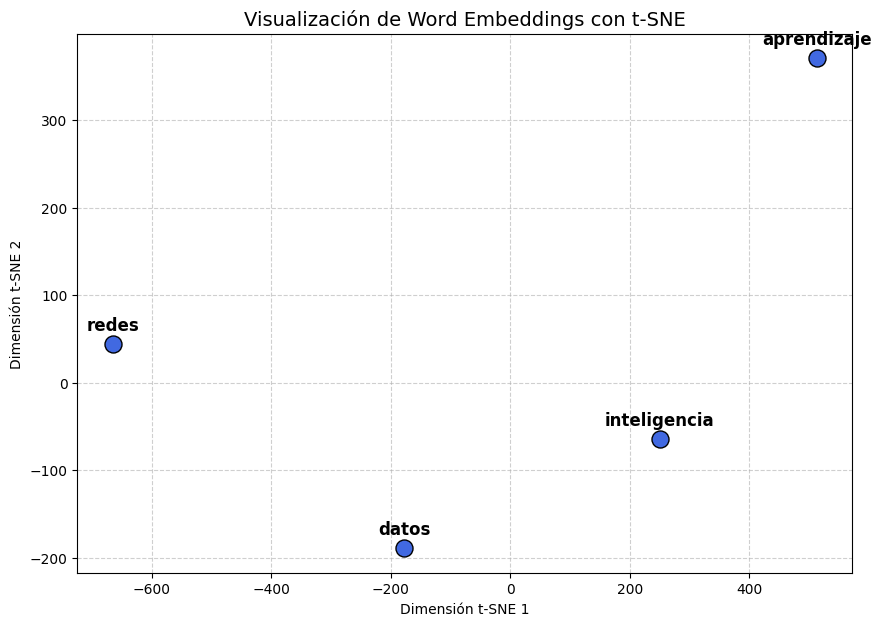

✓ Visualización completada


In [ ]:
# TODO: Visualizar embeddings con t-SNE
#
# INSTRUCCIONES:
# 1. Selecciona 5 palabras que existan en el modelo entrenado
# 2. Obtén sus vectores del modelo
# 3. Usa t-SNE para reducir a 2 dimensiones (perplexity=2)
# 4. Crea un gráfico scatter con los puntos
# 5. Añade anotaciones con los nombres de las palabras
# 6. Añade título y etiquetas a los ejes
#
# PISTAS:
# - TSNE viene de sklearn.manifold
# - Usa plt.scatter() para graficar los puntos
# - Usa plt.annotate() para añadir etiquetas
# - Usa fit_transform() para ajustar y transformar los dados

from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np

# 1. Selecciona 5 palabras que existan en el modelo entrenado (del Punto 3)
palabras = ['inteligencia', 'aprendizaje', 'máquina', 'redes', 'datos']

# 2. Obtén sus vectores del modelo
# Extraemos los vectores numéricos del vocabulario aprendido por Word2Vec
vectores = [model.wv[p] for p in palabras if p in model.wv]
etiquetas = [p for p in palabras if p in model.wv]

# Convertimos a un array de numpy para que scikit-learn pueda procesarlo
X = np.array(vectores)

# 3. Usa t-SNE para reducir a 2 dimensiones (perplexity=2)
# random_state=42 asegura que el gráfico sea el mismo cada vez que lo corras
tsne = TSNE(n_components=2, perplexity=2, random_state=42, init='pca', learning_rate='auto')
vectors_2d = tsne.fit_transform(X)

# 4. Crea un gráfico scatter con los puntos
plt.figure(figsize=(10, 7))
plt.scatter(vectors_2d[:, 0], vectors_2d[:, 1], s=150, color='royalblue', edgecolors='black')

# 5. Añade anotaciones con los nombres de las palabras
for i, label in enumerate(etiquetas):
    plt.annotate(label, (vectors_2d[i, 0], vectors_2d[i, 1]), 
                 textcoords="offset points", 
                 xytext=(0,10), 
                 ha='center', 
                 fontsize=12,
                 fontweight='bold')

# 6. Añade título y etiquetas a los ejes
plt.title("Visualización de Word Embeddings con t-SNE", fontsize=14)
plt.xlabel("Dimensión t-SNE 1")
plt.ylabel("Dimensión t-SNE 2")
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()
print("✓ Visualización completada")

## 5. Clasificación de Textos con Embeddings

In [8]:
# TODO: Clasificar textos usando embeddings
#
# INSTRUCCIONES:
# 1. Define una función que calcule el embedding promedio de un texto
#    - Tokeniza el texto
#    - Obtén vectores de palabras que existan en el modelo
#    - Retorna el promedio de esos vectores
# 2. Crea un dataset con 4 textos de ejemplo y sus etiquetas (positivo=1, negativo=0)
# 3. Obtén los embeddings promedios para cada texto
# 4. Entrena un clasificador LogisticRegression
# 5. Evalúa la precisión en los datos de entrenamiento
# 6. Haz una predicción en un nuevo texto de prueba
#
# PISTAS:
# - np.mean() para promediar vectores
# - LogisticRegression de sklearn.linear_model
# - clf.fit() para entrenar
# - clf.score() para evaluar
# - clf.predict() para predecir

from sklearn.linear_model import LogisticRegression

def get_embedding_avg(texto, modelo):
    palabras = word_tokenize(texto.lower())
    Vectores = [modelo.wv[p] for p in palabras if p in modelo.wv]
    if not vectores:
        return np.zeros(modelo.vector_size)
    return np.zeros(modelo.vector_size) if not vectores else np.mean(vectores, axis=0)
    # Escribe la función aquí
    pass

# Dataset de ejemplo (puedes crear tus propios ejemplos)
textos = ["La inteligencia artificial es asombrosa",
    "El aprendizaje automático es el futuro",
    "No entiendo nada de esta tecnología",
    "Las máquinas son muy complicadas y malas"]  # Completa con 4 textos
etiquetas = [1, 1, 0, 0]  # Completa con sus etiquetas (0 o 1)

# Escribe tu código aquí

X = np.array([get_embedding_avg(t, model) for t in textos])
y = np.array(etiquetas)


clf = LogisticRegression()
clf.fit(X, y)


precision = clf.score(X, y)
print(f"✓ Clasificador entrenado")
print(f"Precisión en entrenamiento: {precision * 100:.2f}%")


nuevo_texto = "Una película asombrosa"
vector_prueba = get_embedding_avg(nuevo_texto, model).reshape(1, -1)
prediccion = clf.predict(vector_prueba)

resultado = "Positiva" if prediccion[0] == 1 else "Negativa"
print(f"\nTexto de prueba: '{nuevo_texto}'")
print(f"Predicción: {resultado}")

✓ Clasificador entrenado
Precisión en entrenamiento: 50.00%

Texto de prueba: 'Una película asombrosa'
Predicción: Negativa


## 6. Conclusiones

En este taller hemos aprendido:
- Conceptos fundamentales de embeddings
- Entrenamiento de Word2Vec
- Visualización y análisis
- Aplicación en clasificación de textos

¡Felicidades por completar el taller!